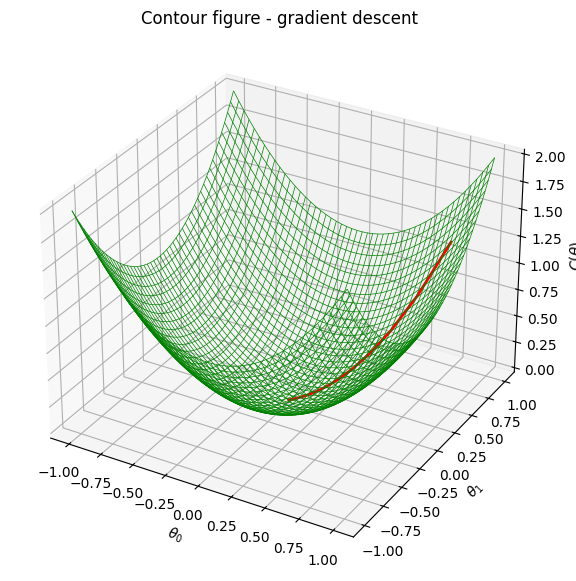

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cost function J(θ0, θ1)
def cost(theta0, theta1):
    return theta0**2 + theta1**2

# Gradient of the cost function
def grad(theta0, theta1):
    return np.array([2*theta0, 2*theta1])

# Generate meshgrid for 3D surface
t0 = np.linspace(-1, 1, 50)
t1 = np.linspace(-1, 1, 50)
T0, T1 = np.meshgrid(t0, t1)
Z = cost(T0, T1)

# Gradient descent settings
alpha = 0.1
theta = np.array([0.8, 0.8])   # starting point
path = [theta.copy()]

for _ in range(20):
    theta = theta - alpha * grad(theta[0], theta[1])
    path.append(theta.copy())

path = np.array(path)
path_z = cost(path[:,0], path[:,1])

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(T0, T1, Z, color='green', linewidth=0.5)
ax.plot(path[:,0], path[:,1], path_z, color='red', linewidth=2)

ax.set_title("Contour figure - gradient descent")
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel(r'$C(\theta)$')

plt.show()


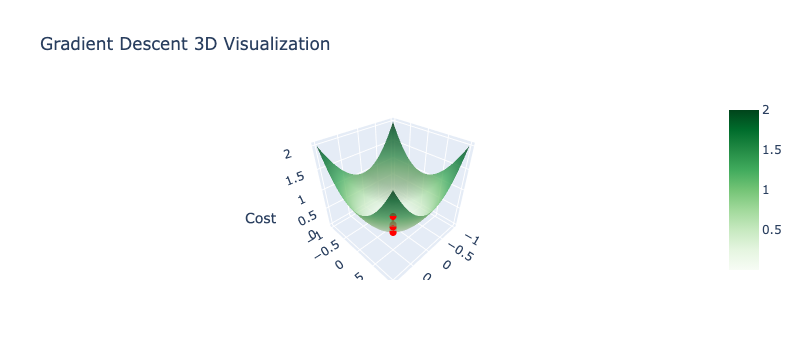

In [7]:
import numpy as np
import plotly.graph_objects as go

# Cost function
def cost(theta0, theta1):
    return theta0**2 + theta1**2

# Gradient
def grad(theta0, theta1):
    return np.array([2*theta0, 2*theta1])

# Surface
t0 = np.linspace(-1, 1, 50)
t1 = np.linspace(-1, 1, 50)
T0, T1 = np.meshgrid(t0, t1)
Z = cost(T0, T1)

# Gradient descent
alpha = 0.1
theta = np.array([0.8, 0.8])
path = [theta.copy()]

for _ in range(20):
    theta = theta - alpha * grad(theta[0], theta[1])
    path.append(theta.copy())

path = np.array(path)
path_z = cost(path[:, 0], path[:, 1])

# Plotly Figure
fig = go.Figure()

# Add surface
fig.add_trace(go.Surface(x=T0, y=T1, z=Z, colorscale='Greens', opacity=0.8))

# Add descent path
fig.add_trace(
    go.Scatter3d(
        x=path[:,0], y=path[:,1], z=path_z,
        mode='lines+markers',
        line=dict(width=5, color='red'),
        marker=dict(size=4, color='red')
    )
)

fig.update_layout(
    title="Gradient Descent 3D Visualization",
    scene=dict(
        xaxis_title="θ0",
        yaxis_title="θ1",
        zaxis_title="Cost"
    )
)

fig.show()


# # Non Convex Fuction 

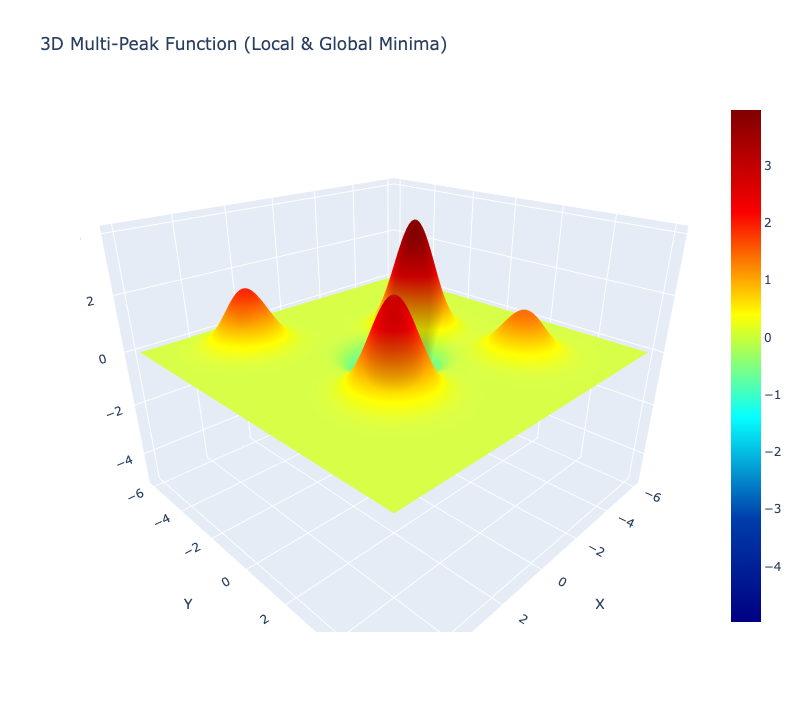

In [1]:
import numpy as np
import plotly.graph_objects as go

# Define a multi-peak function (like in your image)
def f(x, y):
    return (
        3 * np.exp(-((x-2)**2 + (y-2)**2)) +
        4 * np.exp(-((x+2)**2 + (y+1)**2)) +
        2 * np.exp(-((x-3)**2 + (y+4)**2)) +
        1.5 * np.exp(-((x+3)**2 + (y-3)**2)) -
        5 * np.exp(-((x-0)**2 + (y-0)**2))
    )

# Create meshgrid
x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Plotly 3D Surface
fig = go.Figure(data=[
    go.Surface(
        x=X, y=Y, z=Z,
        colorscale="Jet",
        showscale=True
    )
])

fig.update_layout(
    title="3D Multi-Peak Function (Local & Global Minima)",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        camera=dict(eye=dict(x=1.2, y=1.2, z=0.8))
    ),
    width=900,
    height=700
)

fig.show()


# this is called a saddle fuciton 

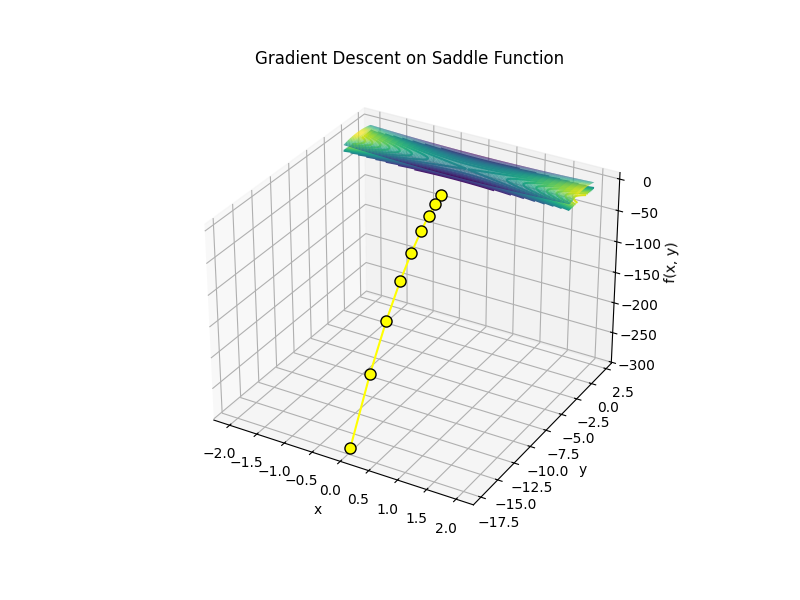

In [4]:
# %matplotlib notebook
# or:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x, y):
    return x**2 - y**2

def grad(x, y):
    return np.array([2*x, -2*y])

# Grid
x = np.linspace(-2, 2, 80)
y = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Gradient descent
p = np.array([0.0, -4.0])
lr = 0.1
path = [p.copy()]

for _ in range(8):
    p = p - lr * grad(p[0], p[1])
    path.append(p.copy())

path = np.array(path)
path_z = f(path[:,0], path[:,1])

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.contour(X, Y, Z, 15, cmap='viridis', offset=np.min(Z)-5)

ax.plot(path[:,0], path[:,1], path_z, '-o',
        color='yellow', markersize=8, markeredgecolor='black')

ax.set_title("Gradient Descent on Saddle Function")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")

plt.show()
